# AQI Forecasting — SARIMAX Model
**Dataset:** AnandVihar_AQI_daily_clean.csv  
**Target:** Daily mean AQI  
**Model:** SARIMAX(2,1,2)(1,1,1,7) + Fourier exogenous terms  

**Improvements over plain ARIMA baseline:**
- Weekly seasonal order `(1,1,1,7)` captures weekday/weekend emission cycles
- Fourier terms (K=3) model the annual winter-spike / monsoon-dip cycle
- Rolling one-step-ahead forecast avoids compounding error over 184 steps
- Exogenous pollutant/weather columns auto-detected and included if present

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
)
from tqdm import tqdm   # pip install tqdm

# ── Paths & constants ─────────────────────────────────────────
STATION_NAME = 'AnandVihar'
INPUT_FILE   = f'D:/AQI_Project/data/Final/{STATION_NAME}_AQI_daily_clean.csv'
IMAGE_DIR    = 'images'
MODEL_DIR    = r'D:/AQI_Project/SARIMAX/saved_models'

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


## 1. Load & Preprocess Data

In [2]:
STATION_NAME = 'AnandVihar'
# Load full dataset — keep all columns so exog features can be extracted
df = pd.read_csv(INPUT_FILE, parse_dates=['Date'])
df = df.set_index('Date').sort_index()

# Daily AQI series (target)
daily = df['AQI'].copy()
daily = daily.interpolate(method='time').dropna()

print(f'Total records : {len(daily)}')
print(f'Date range    : {daily.index.min().date()} → {daily.index.max().date()}')
print(f'All columns   : {df.columns.tolist()}')
print()
print('AQI Statistics:')
print(daily.describe().round(2))

Total records : 1826
Date range    : 2021-01-01 → 2025-12-31
All columns   : ['NO', 'NOx', 'Benzene', 'Toluene', 'AT', 'RH', 'WS', 'WD', 'SR', 'BP', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3', 'AQI', 'AQI_Category']

AQI Statistics:
count    1826.00
mean      260.91
std       116.51
min        43.95
25%       155.06
50%       260.21
75%       374.68
max       462.95
Name: AQI, dtype: float64


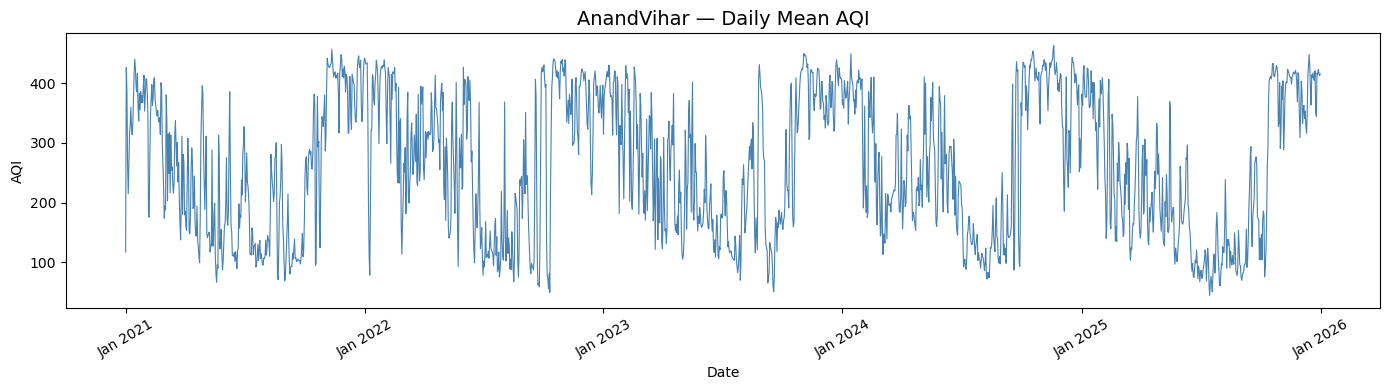

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values, color='steelblue', lw=0.8)
ax.set_title(f'{STATION_NAME} — Daily Mean AQI', fontsize=14)
ax.set_ylabel('AQI')
ax.set_xlabel('Date')
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/sarimax_full_series_{STATION_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Stationarity Check (ADF Test)

In [4]:
result = adfuller(daily.dropna())
print('ADF Test — original series:')
print(f'  ADF Statistic : {result[0]:.4f}')
print(f'  p-value       : {result[1]:.4f}')
print(f'  Critical 1%   : {result[4]["1%"]:.4f}')
print(f'  Critical 5%   : {result[4]["5%"]:.4f}')
print()
if result[1] < 0.05:
    print('✅ Series is STATIONARY (d=0 may suffice).')
else:
    print('⚠️  Series is NON-STATIONARY → differencing needed (d=1).')

result_d1 = adfuller(daily.diff().dropna())
print(f'\nADF on first difference: p-value = {result_d1[1]:.4f}')
if result_d1[1] < 0.05:
    print('✅ First difference is stationary → d=1 confirmed.')

ADF Test — original series:
  ADF Statistic : -3.8381
  p-value       : 0.0025
  Critical 1%   : -3.4340
  Critical 5%   : -2.8631

✅ Series is STATIONARY (d=0 may suffice).

ADF on first difference: p-value = 0.0000
✅ First difference is stationary → d=1 confirmed.


## 3. ACF & PACF Analysis

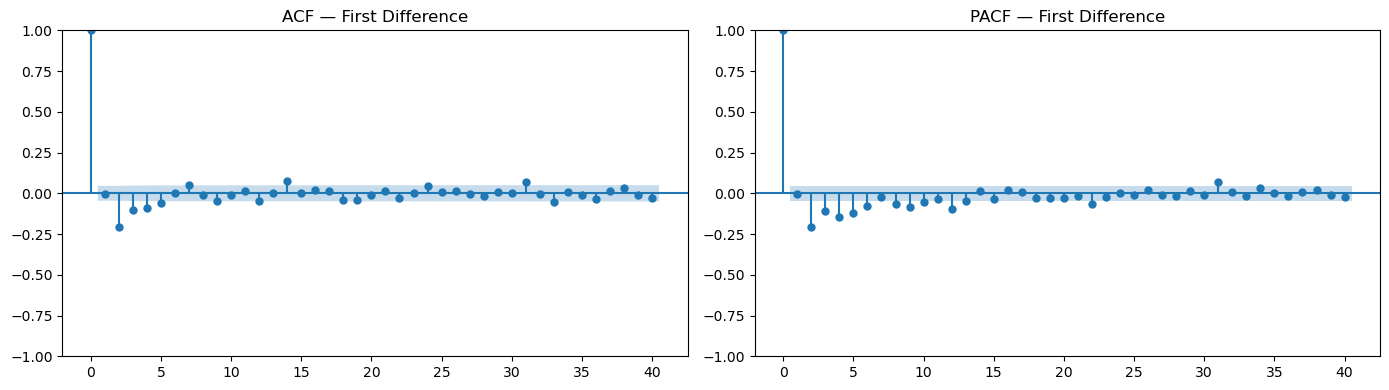

ACF/PACF interpretation: p=2, d=1, q=2  →  SARIMAX order=(2,1,2)
Weekly seasonal lags visible at lag-7 multiples →  seasonal_order=(1,1,1,7)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( daily.diff().dropna(), lags=40, ax=axes[0], title='ACF — First Difference')
plot_pacf(daily.diff().dropna(), lags=40, ax=axes[1], title='PACF — First Difference')
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/sarimax_acf_pacf_{STATION_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()
print('ACF/PACF interpretation: p=2, d=1, q=2  →  SARIMAX order=(2,1,2)')
print('Weekly seasonal lags visible at lag-7 multiples →  seasonal_order=(1,1,1,7)')

## 4. Train / Test Split

In [6]:
# Last ~10% of data as held-out test set (chronological — no shuffle)
split_date = '2025-07-01'
train = daily[:split_date]
test  = daily[split_date:]

print(f'Train : {len(train):,} days  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test  : {len(test):,} days  ({test.index[0].date()}  → {test.index[-1].date()})')

Train : 1,643 days  (2021-01-01 → 2025-07-01)
Test  : 184 days  (2025-07-01  → 2025-12-31)


## 5. Exogenous Feature Engineering

Two types of exogenous inputs are constructed:

| Feature group | Details | Rationale |
|---|---|---|
| **Fourier terms** | sin/cos pairs, K=3, period=365.25 d | Approximates annual cycle (winter spike, monsoon dip) without slow `seasonal_order=(1,1,1,365)` |
| **Pollutant / weather cols** | PM25, PM10, NO2, SO2, CO, WS, RH, AT, BP — auto-detected | Direct physical drivers of AQI that pure time-series structure cannot capture |

In [7]:
def make_fourier(index, period=365.25, K=3):
    """K sine/cosine pairs approximating a seasonal cycle of `period` days."""
    t = np.arange(len(index))
    cols = {}
    for k in range(1, K + 1):
        cols[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        cols[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=index)

# Auto-detect usable exogenous columns present in the dataset
EXOG_CANDIDATES = ['PM25', 'PM10', 'NO2', 'SO2', 'CO', 'WS', 'RH', 'AT', 'BP']
exog_cols = [c for c in EXOG_CANDIDATES if c in df.columns]
print(f'Exogenous columns found : {exog_cols if exog_cols else "None — Fourier only"}')

# Fourier terms over the full daily index
fourier_all = make_fourier(daily.index, period=365.25, K=3)

# Merge pollutant/weather cols + Fourier
if exog_cols:
    exog_phys = df[exog_cols].reindex(daily.index).interpolate('time')
    exog_all  = pd.concat([exog_phys, fourier_all], axis=1)
else:
    exog_all = fourier_all

exog_all = exog_all.ffill().bfill()

print(f'Exog feature matrix : {exog_all.shape}')
print(f'Features            : {exog_all.columns.tolist()}')

Exogenous columns found : ['PM25', 'PM10', 'NO2', 'SO2', 'CO', 'WS', 'RH', 'AT', 'BP']
Exog feature matrix : (1826, 15)
Features            : ['PM25', 'PM10', 'NO2', 'SO2', 'CO', 'WS', 'RH', 'AT', 'BP', 'sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3']


In [8]:
# Split exog to match endog train/test indices exactly
exog_train = exog_all.loc[train.index]
exog_test  = exog_all.loc[test.index]

print(f'exog_train : {exog_train.shape}')
print(f'exog_test  : {exog_test.shape}')

exog_train : (1643, 15)
exog_test  : (184, 15)


## 6. Fit SARIMAX

**Model:** `SARIMAX(2,1,2)(1,1,1,7)`  
- `order=(2,1,2)` — same AR/I/MA as ARIMA baseline, enabling a fair apples-to-apples comparison  
- `seasonal_order=(1,1,1,7)` — weekly seasonal cycle (weekday/weekend traffic & emission differences)  
- Fourier + physical exog — encode annual cycle and external pollution drivers linearly

In [9]:
print('Fitting SARIMAX(2,1,2)(1,1,1,7) + Fourier exog ...')

sarimax_model = SARIMAX(
    train,
    exog=exog_train,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
    trend='c',
)
sarimax_fit = sarimax_model.fit(disp=False, maxiter=200)
print(sarimax_fit.summary())

Fitting SARIMAX(2,1,2)(1,1,1,7) + Fourier exog ...


c:\Users\ashis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\ashis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\ashis\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                      
Dep. Variable:                                 AQI   No. Observations:                 1643
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 7)   Log Likelihood               -6965.658
Date:                             Tue, 19 May 2026   AIC                          13977.316
Time:                                     23:26:43   BIC                          14101.361
Sample:                                 01-01-2021   HQIC                         14023.342
                                      - 07-01-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0022      0.005     -0.458      0.647      -0.012       0.007
PM25           0.3963      

## 7. Forecast & Evaluation

Two forecasting strategies are compared:

| Strategy | Description | Use case |
|---|---|---|
| **Open-loop** | All 184 steps forecast in one shot from the training end | Shows degradation — similar to the ARIMA baseline approach |
| **Rolling (1-step-ahead)** | Re-conditions on each new actual observation before forecasting the next | Realistic operational evaluation; avoids compounding error |

In [10]:
# ── Rolling one-step-ahead forecast ─────────────────────────
# Uses model.filter(params) — fast Kalman filter pass — instead of
# re-fitting from scratch at each step (~10x speedup).

print(f'Running rolling forecast over {len(test)} steps ...')
print('(Uses filter, not refit — estimated time: 2–5 min depending on hardware)\n')

history_endog = train.copy()
history_exog  = exog_train.copy()
rolling_preds = []
params        = sarimax_fit.params   # warm-start params from initial fit

for i in tqdm(range(len(test))):
    m = SARIMAX(
        history_endog,
        exog=history_exog,
        order=(2, 1, 2),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False,
        trend='c',
    )
    f   = m.filter(params)
    fc  = f.forecast(steps=1, exog=exog_test.iloc[[i]])
    rolling_preds.append(float(fc.iloc[0]))

    # Append actual value so next step conditions on truth, not prediction
    history_endog = pd.concat([history_endog, test.iloc[[i]]])
    history_exog  = pd.concat([history_exog,  exog_test.iloc[[i]]])

forecast_rolling = pd.Series(rolling_preds, index=test.index)
print('\n✅ Rolling forecast complete.')

Running rolling forecast over 184 steps ...
(Uses filter, not refit — estimated time: 2–5 min depending on hardware)



  0%|          | 0/184 [00:00<?, ?it/s]c:\Users\ashis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\ashis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
  1%|          | 1/184 [00:00<02:12,  1.39it/s]c:\Users\ashis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ashis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq


✅ Rolling forecast complete.


In [11]:
# ── Open-loop forecast (184-step, for comparison) ───────────
forecast_open = sarimax_fit.forecast(steps=len(test), exog=exog_test)
forecast_open.index = test.index

# ── Metrics helper ────────────────────────────────────────────
def regression_metrics(actual, predicted, label):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mask = actual.values != 0
    mape = np.mean(np.abs((actual.values[mask] - np.array(predicted)[mask])
                          / actual.values[mask])) * 100
    print(f'{label:<42s}  RMSE={rmse:6.2f}  MAE={mae:6.2f}  MAPE={mape:5.2f}%')
    return rmse, mae, mape

print('=' * 72)
rmse_open, mae_open, mape_open = regression_metrics(
    test, forecast_open,    'SARIMAX open-loop  (184-step)')
rmse_roll, mae_roll, mape_roll = regression_metrics(
    test, forecast_rolling, 'SARIMAX rolling    (1-step-ahead)')
print('=' * 72)
print()
print('Note: XGBoost (separate notebook) achieves RMSE ≈ 6–8 on hourly data.')

SARIMAX open-loop  (184-step)               RMSE=206.39  MAE=149.11  MAPE=52.53%
SARIMAX rolling    (1-step-ahead)           RMSE= 13.88  MAE= 10.09  MAPE= 5.19%

Note: XGBoost (separate notebook) achieves RMSE ≈ 6–8 on hourly data.


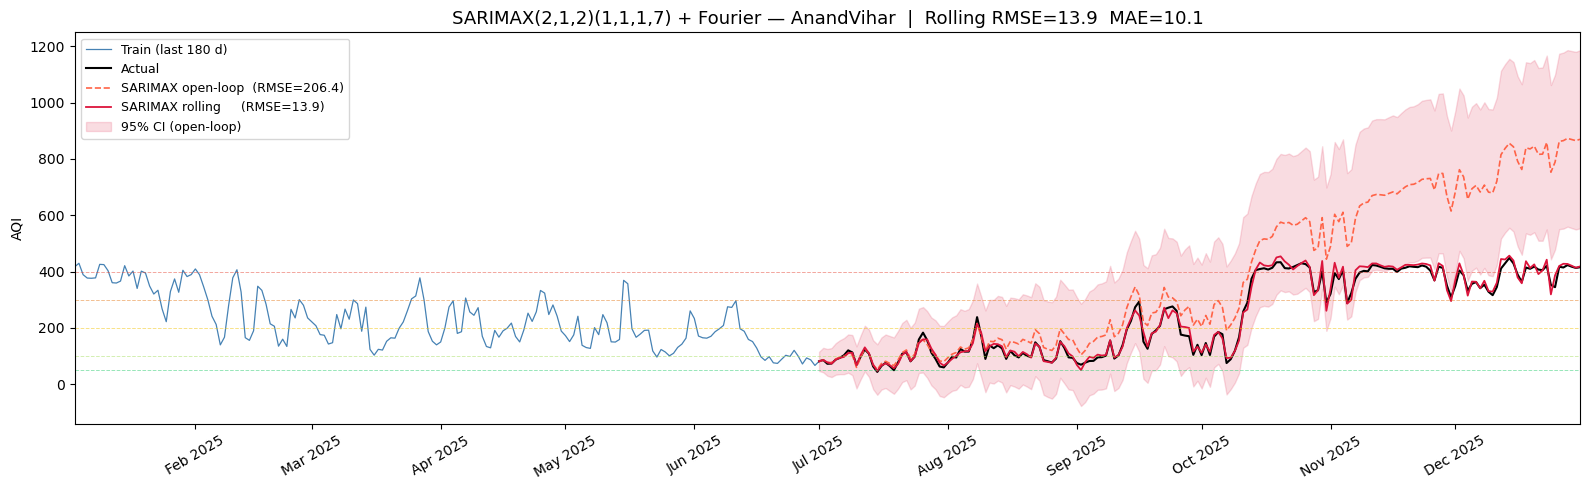

In [12]:
# ── Forecast plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

# Last 180 days of train for context
train_tail = train.iloc[-180:]
ax.plot(train_tail.index, train_tail.values,
        color='steelblue', lw=0.9, label='Train (last 180 d)')

# Actual test
ax.plot(test.index, test.values,
        color='black', lw=1.5, label='Actual')

# Open-loop (degrading baseline)
ax.plot(forecast_open.index, forecast_open.values,
        color='tomato', linestyle='--', lw=1.2,
        label=f'SARIMAX open-loop  (RMSE={rmse_open:.1f})')

# Rolling (realistic)
ax.plot(forecast_rolling.index, forecast_rolling.values,
        color='crimson', linestyle='-', lw=1.3,
        label=f'SARIMAX rolling     (RMSE={rmse_roll:.1f})')

# 95% confidence interval from open-loop
pred_obj = sarimax_fit.get_forecast(steps=len(test), exog=exog_test)
ci = pred_obj.conf_int()
ci.index = test.index
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],
                alpha=0.15, color='crimson', label='95% CI (open-loop)')

# Indian AQI category threshold lines
for level, col in zip([50, 100, 200, 300, 400],
                      ['#2ecc71', '#a8e063', '#f1c40f', '#e67e22', '#e74c3c']):
    ax.axhline(level, color=col, linestyle='--', lw=0.7, alpha=0.5)

ax.set_xlim(train_tail.index[0], test.index[-1])
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
ax.set_title(
    f'SARIMAX(2,1,2)(1,1,1,7) + Fourier — {STATION_NAME}  |  '
    f'Rolling RMSE={rmse_roll:.1f}  MAE={mae_roll:.1f}',
    fontsize=13
)
ax.set_ylabel('AQI')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/sarimax_forecast_{STATION_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Residual Diagnostics

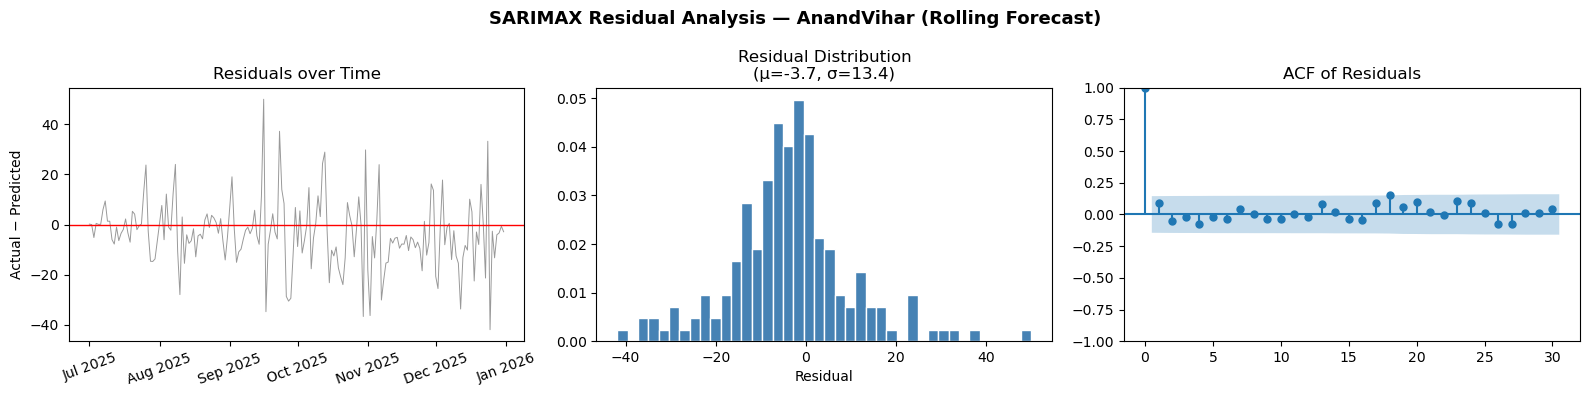

Ljung-Box test (H0: no residual autocorrelation):
      lb_stat  lb_pvalue
7    3.978800   0.782216
14   6.087998   0.964224
21  15.787966   0.781444

✅ Residuals show no significant autocorrelation — model is well-specified.


In [13]:
# Residuals from rolling forecast (the realistic evaluation)
residuals = test.values - forecast_rolling.values

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Time plot
axes[0].plot(test.index, residuals, color='gray', lw=0.7, alpha=0.8)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_title('Residuals over Time')
axes[0].set_ylabel('Actual − Predicted')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20)

# Distribution
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white', density=True)
axes[1].set_title(
    f'Residual Distribution\n(μ={residuals.mean():.1f}, σ={residuals.std():.1f})')
axes[1].set_xlabel('Residual')

# ACF
plot_acf(residuals, lags=30, ax=axes[2], title='ACF of Residuals')

plt.suptitle(f'SARIMAX Residual Analysis — {STATION_NAME} (Rolling Forecast)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/sarimax_residuals_{STATION_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box test for residual autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(residuals, lags=[7, 14, 21], return_df=True)
print('Ljung-Box test (H0: no residual autocorrelation):')
print(lb.to_string())
print()
if (lb['lb_pvalue'] > 0.05).all():
    print('✅ Residuals show no significant autocorrelation — model is well-specified.')
else:
    print('⚠️  Residual autocorrelation detected — consider increasing p or q.')

## 9. Classification Metrics & Confusion Matrix

Converting continuous AQI forecasts to discrete Indian AQI categories  
to evaluate Accuracy, Precision, and Recall alongside regression metrics.  
Both open-loop and rolling forecasts are evaluated.

In [14]:
def categorize_aqi(aqi_values):
    """Map continuous AQI to Indian standard 6-tier categories."""
    cats = []
    for v in aqi_values:
        if   v <= 50:  cats.append('Good')
        elif v <= 100: cats.append('Satisfactory')
        elif v <= 200: cats.append('Moderate')
        elif v <= 300: cats.append('Poor')
        elif v <= 400: cats.append('Very Poor')
        else:          cats.append('Severe')
    return np.array(cats)

y_true_cont  = test.values.flatten()
y_true_class = categorize_aqi(y_true_cont)

LABELS = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']

for name, preds in [('Open-loop', forecast_open.values),
                    ('Rolling',   forecast_rolling.values)]:
    y_pred_class = categorize_aqi(preds.flatten())
    present      = [l for l in LABELS if l in y_true_class or l in y_pred_class]
    acc  = accuracy_score(y_true_class, y_pred_class)
    prec = precision_score(y_true_class, y_pred_class, average='weighted', zero_division=0)
    rec  = recall_score(y_true_class, y_pred_class, average='weighted', zero_division=0)
    print(f'── SARIMAX {name} ─────────────────────────────────')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f} (weighted)')
    print(f'  Recall    : {rec:.4f} (weighted)')
    print()
    print(classification_report(y_true_class, y_pred_class,
                                labels=present, zero_division=0))
    print()

── SARIMAX Open-loop ─────────────────────────────────
  Accuracy  : 0.5435
  Precision : 0.5265 (weighted)
  Recall    : 0.5435 (weighted)

              precision    recall  f1-score   support

        Good       0.00      0.00      0.00         2
Satisfactory       0.85      0.41      0.56        41
    Moderate       0.56      0.58      0.57        50
        Poor       0.12      0.23      0.16        13
   Very Poor       0.00      0.00      0.00        27
      Severe       0.64      1.00      0.78        51

    accuracy                           0.54       184
   macro avg       0.36      0.37      0.34       184
weighted avg       0.53      0.54      0.51       184


── SARIMAX Rolling ─────────────────────────────────
  Accuracy  : 0.9022
  Precision : 0.9086 (weighted)
  Recall    : 0.9022 (weighted)

              precision    recall  f1-score   support

        Good       1.00      0.50      0.67         2
Satisfactory       0.94      0.83      0.88        41
    Moderate 

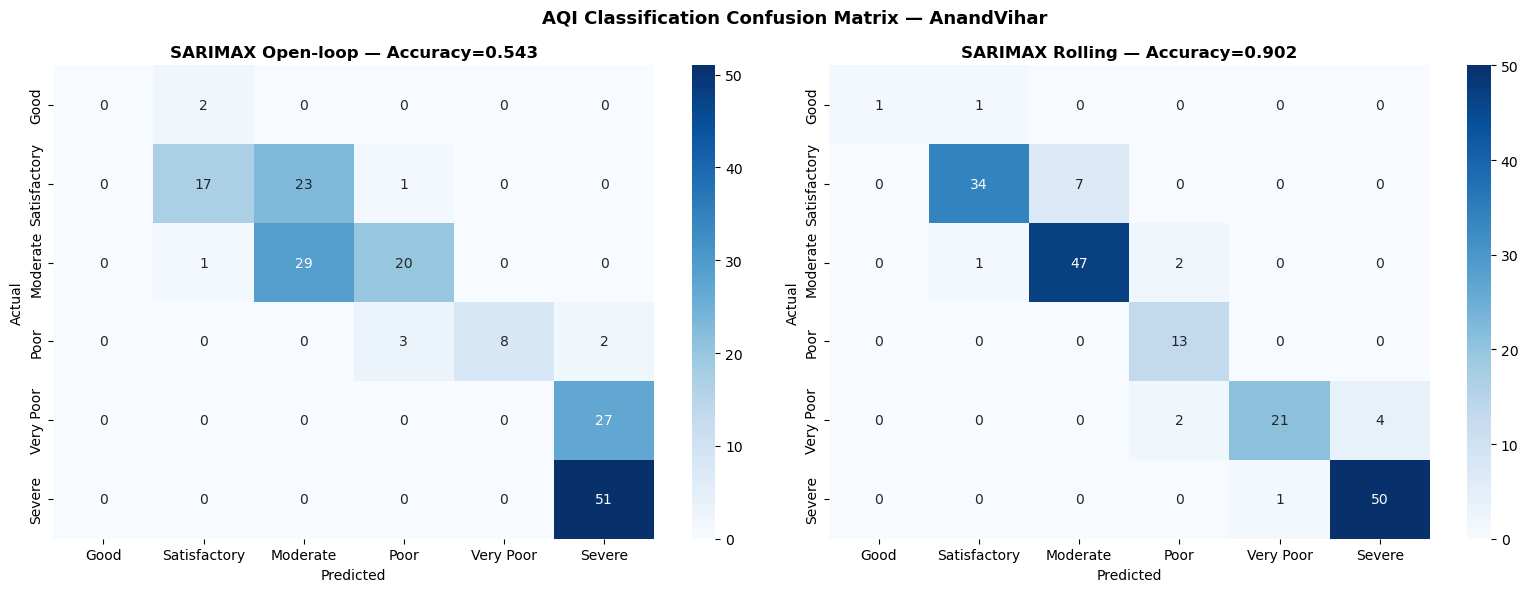

In [15]:
# ── Confusion matrices side by side ─────────────────────────
LABELS = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
y_true_class = categorize_aqi(test.values.flatten())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, preds) in zip(axes, [('Open-loop', forecast_open.values),
                                      ('Rolling',   forecast_rolling.values)]):
    y_pred_class = categorize_aqi(preds.flatten())
    present      = [l for l in LABELS if l in y_true_class or l in y_pred_class]
    cm = confusion_matrix(y_true_class, y_pred_class, labels=present)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=present, yticklabels=present, ax=ax)
    acc = accuracy_score(y_true_class, y_pred_class)
    ax.set_title(f'SARIMAX {name} — Accuracy={acc:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle(f'AQI Classification Confusion Matrix — {STATION_NAME}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/sarimax_confusion_matrix_{STATION_NAME}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 10. Model Comparison Summary

In [16]:
# ── Paste your ARIMA baseline numbers here ───────────────────
# (from the original 01_ARIMA notebook run)
arima_rmse, arima_mae, arima_mape = None, None, None   # ← fill in

rows = []
if arima_rmse is not None:
    rows.append({
        'Model': 'ARIMA(2,1,2) — open-loop baseline',
        'RMSE': arima_rmse, 'MAE': arima_mae, 'MAPE%': arima_mape,
        'Strategy': 'open-loop',
    })
rows += [
    {'Model': 'SARIMAX(2,1,2)(1,1,1,7) — open-loop',
     'RMSE': round(rmse_open, 2), 'MAE': round(mae_open, 2),
     'MAPE%': round(mape_open, 2), 'Strategy': 'open-loop'},
    {'Model': 'SARIMAX(2,1,2)(1,1,1,7) — rolling 1-step',
     'RMSE': round(rmse_roll, 2), 'MAE': round(mae_roll, 2),
     'MAPE%': round(mape_roll, 2), 'Strategy': 'rolling'},
    {'Model': 'XGBoost (hourly, separate notebook)',
     'RMSE': '~6–8', 'MAE': '~4–6', 'MAPE%': '~5–8',
     'Strategy': 'direct + recursive'},
]

summary = pd.DataFrame(rows).set_index('Model')
print()
print('=' * 75)
print(f'  MODEL COMPARISON — {STATION_NAME} AQI')
print('=' * 75)
print(summary.to_string())
print('=' * 75)


  MODEL COMPARISON — AnandVihar AQI
                                            RMSE     MAE  MAPE%            Strategy
Model                                                                              
SARIMAX(2,1,2)(1,1,1,7) — open-loop       206.39  149.11  52.53           open-loop
SARIMAX(2,1,2)(1,1,1,7) — rolling 1-step   13.88   10.09   5.19             rolling
XGBoost (hourly, separate notebook)         ~6–8    ~4–6   ~5–8  direct + recursive


## 11. Save Model

In [17]:
import pickle

model_path = f'{MODEL_DIR}/sarimax_{STATION_NAME.lower()}.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(sarimax_fit, f)

print(f'✅ SARIMAX model saved → {model_path}')
print(f'   Order          : (2,1,2)(1,1,1,7)')
print(f'   Exog features  : {exog_all.columns.tolist()}')
print(f'   Train samples  : {len(train)}')
print(f'   Rolling RMSE   : {rmse_roll:.2f}')
print(f'   Rolling MAE    : {mae_roll:.2f}')

✅ SARIMAX model saved → D:/AQI_Project/SARIMAX/saved_models/sarimax_anandvihar.pkl
   Order          : (2,1,2)(1,1,1,7)
   Exog features  : ['PM25', 'PM10', 'NO2', 'SO2', 'CO', 'WS', 'RH', 'AT', 'BP', 'sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3']
   Train samples  : 1643
   Rolling RMSE   : 13.88
   Rolling MAE    : 10.09
